In [1]:
# ─────────────────────────────────────────────────────
# IMPORTS grouped by purpose:
#   DATA        → pandas, numpy
#   MODELS      → the three baseline classifiers
#   METRICS     → every metric in our priority list
#   PLOTTING    → confusion matrix heatmap, ROC curve
# ─────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.tree           import DecisionTreeClassifier
from sklearn.neighbors      import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,      # MCC / Phi coefficient
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ All imports loaded')

✅ All imports loaded


In [3]:
# ─────────────────────────────────────────────────────
# WHY repeat preprocessing instead of loading the CSV?
#
# The saved CSV is PRE-SCALE (human-readable units).
# We need the SCALED arrays for KNN and Logistic Regression.
# Re-running the pipeline from cleaned CSV takes < 1 second
# and guarantees we use the exact same scaler fit.
#
# In a production pipeline you would load X_train_scaled
# from a pickle; here we keep it explicit for learning.
# ─────────────────────────────────────────────────────

# Load the cleaned (imputed + capped + engineered) CSV
df = pd.read_csv('../data/processed/diabetes_clean.csv')

X = df.drop(columns=['Outcome'])
y = df['Outcome']

# Stratified split — same seed as Notebook 02
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale — fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')
print(f'Target balance — Train: {y_train.mean()*100:.1f}% diabetic | Test: {y_test.mean()*100:.1f}% diabetic')

Train: (614, 11) | Test: (154, 11)
Target balance — Train: 34.9% diabetic | Test: 35.1% diabetic


In [4]:
# ─────────────────────────────────────────────────────
# This function is reused for EVERY model in this notebook
# and in Notebook 04. It computes all 5 priority metrics
# and returns them as a dictionary.
#
# WHY average='binary'?
#   Our target has exactly 2 classes (0 and 1).
#   'binary' computes precision/recall/f1 for the POSITIVE
#   class (1 = diabetic), which is exactly what we care about.
#
# WHY pos_label=1?
#   Explicit is better than implicit. We declare that
#   "1" is the positive class (diabetic) so sklearn knows
#   which class's recall we want maximised.
# ─────────────────────────────────────────────────────

def evaluate_model(model_name, y_true, y_pred, y_prob):
    """
    Compute all priority metrics and return as a dict.
    
    Parameters:
        model_name : str  – label for the results table
        y_true     : array – ground truth labels
        y_pred     : array – predicted labels (0 or 1)
        y_prob     : array – predicted probabilities for class 1
    
    Returns:
        dict with all metrics
    """
    return {
        'Model'    : model_name,
        'Recall'   : recall_score(y_true, y_pred, pos_label=1),
        'F1-Score' : f1_score(y_true, y_pred, pos_label=1),
        'MCC (Phi)': matthews_corrcoef(y_true, y_pred),
        'ROC-AUC'  : roc_auc_score(y_true, y_prob),
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, pos_label=1)
    }

# Storage list — we append each model's results here
all_results = []

print('✅ Evaluation function ready')

✅ Evaluation function ready


In [5]:
# ─────────────────────────────────────────────────────
# LOGISTIC REGRESSION — the simplest meaningful classifier
#
# What it does:
#   Fits a linear decision boundary: w1*x1 + w2*x2 + ... + b = 0
#   Then passes the result through a sigmoid → probability in [0,1]
#   If probability ≥ 0.5 → predict 1 (diabetic)
#
# Why it's a good baseline:
#   • Fastest to train
#   • Outputs calibrated probabilities (needed for ROC-AUC)
#   • If this model already scores well, the data has strong
#     linear signal → simpler models may suffice
#
# Hyperparameters explained:
#   max_iter=1000  → maximum optimisation iterations;
#                    100 (default) sometimes isn't enough
#                    for scaled multi-feature data
#   random_state=42 → reproducibility
#   C=1.0 (default) → inverse regularisation strength;
#                      1.0 is neutral, we test more in Notebook 04
# ─────────────────────────────────────────────────────

lr = LogisticRegression(max_iter=1000, random_state=42)

# Train
lr.fit(X_train_scaled, y_train)

# Predict labels AND probabilities
lr_pred = lr.predict(X_train_scaled if False else X_test_scaled)  # test set
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]  # probability of class 1

# Evaluate
lr_results = evaluate_model('Logistic Regression', y_test, lr_pred, lr_prob)
all_results.append(lr_results)

# Print classification report (detailed per-class breakdown)
print('=== Logistic Regression — Classification Report ===')
print(classification_report(y_test, lr_pred, target_names=['Non-Diabetic', 'Diabetic']))

print(f"Recall:    {lr_results['Recall']:.4f}")
print(f"F1-Score:  {lr_results['F1-Score']:.4f}")
print(f"MCC (Phi): {lr_results['MCC (Phi)']:.4f}")
print(f"ROC-AUC:   {lr_results['ROC-AUC']:.4f}")
print(f"Accuracy:  {lr_results['Accuracy']:.4f}")

=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

Non-Diabetic       0.76      0.82      0.79       100
    Diabetic       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154

Recall:    0.5185
F1-Score:  0.5600
MCC (Phi): 0.3529
ROC-AUC:   0.8085
Accuracy:  0.7143


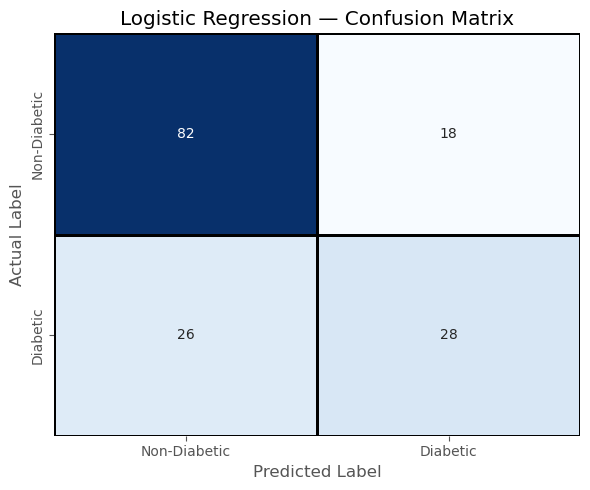

  True Negatives  (TN): 82
  False Positives (FP): 18
  False Negatives (FN): 26  ← diabetic patients MISSED
  True Positives  (TP): 28


In [6]:
# ─────────────────────────────────────────────────────
# CONFUSION MATRIX for Logistic Regression
#
# Layout:
#                  Predicted
#                No      Yes
#   Actual No  [ TN      FP ]
#   Actual Yes [ FN      TP ]
#
# In medical screening:
#   FN (False Negative) = diabetic patient missed → DANGEROUS
#   FP (False Positive) = healthy patient flagged → causes anxiety but not lethal
#
# So we want FN to be as LOW as possible (= high Recall).
# ─────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'],
            ax=ax, linewidths=1, linecolor='black',
            cbar=False)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_title('Logistic Regression — Confusion Matrix')

plt.tight_layout()
plt.show()

print(f"  True Negatives  (TN): {cm[0][0]}")
print(f"  False Positives (FP): {cm[0][1]}")
print(f"  False Negatives (FN): {cm[1][0]}  ← diabetic patients MISSED")
print(f"  True Positives  (TP): {cm[1][1]}")

In [7]:
# ─────────────────────────────────────────────────────
# DECISION TREE — the most interpretable non-linear model
#
# What it does:
#   Recursively splits data on feature thresholds:
#   "If Glucose > 127.5, go right; else go left"
#   Until leaves are pure (all same class) or a stop condition
#
# Why it's a good baseline:
#   • Shows the RAW non-linear splitting power of the features
#   • Very interpretable — you can literally read the tree
#   • Does NOT need scaled data (splits are threshold-based)
#     → We pass X_train (unscaled) here to prove this point
#
# Hyperparameters:
#   max_depth=5     → limits tree depth to 5 levels
#                     Without this, the tree overfits badly
#                     (memorises every training row)
#   min_samples_split=10 → a node must have ≥10 samples to split
#                           prevents overfitting on tiny subgroups
#   min_samples_leaf=5   → each leaf must contain ≥5 samples
#                           smooths out the tree
#   random_state=42      → when features tie, choose randomly
# ─────────────────────────────────────────────────────

dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Decision trees don't need scaling, but we use unscaled
# data to demonstrate that point
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:, 1]

dt_results = evaluate_model('Decision Tree', y_test, dt_pred, dt_prob)
all_results.append(dt_results)

print('=== Decision Tree — Classification Report ===')
print(classification_report(y_test, dt_pred, target_names=['Non-Diabetic', 'Diabetic']))

print(f"Recall:    {dt_results['Recall']:.4f}")
print(f"F1-Score:  {dt_results['F1-Score']:.4f}")
print(f"MCC (Phi): {dt_results['MCC (Phi)']:.4f}")
print(f"ROC-AUC:   {dt_results['ROC-AUC']:.4f}")
print(f"Accuracy:  {dt_results['Accuracy']:.4f}")

=== Decision Tree — Classification Report ===
              precision    recall  f1-score   support

Non-Diabetic       0.75      0.85      0.79       100
    Diabetic       0.62      0.46      0.53        54

    accuracy                           0.71       154
   macro avg       0.69      0.66      0.66       154
weighted avg       0.70      0.71      0.70       154

Recall:    0.4630
F1-Score:  0.5319
MCC (Phi): 0.3406
ROC-AUC:   0.7764
Accuracy:  0.7143


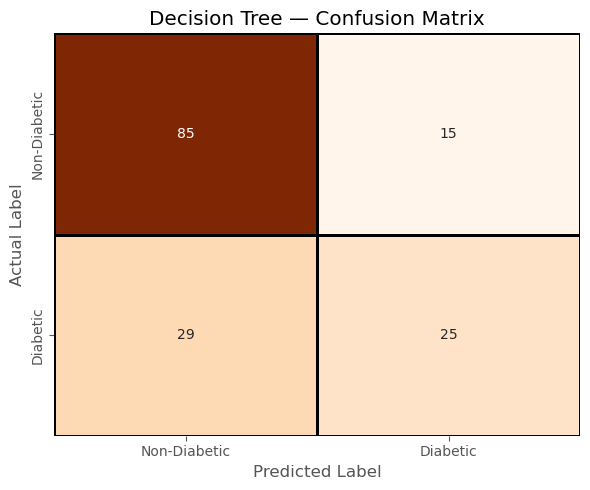

  FN (diabetic missed): 29  | TP (diabetic caught): 25


In [8]:
# Confusion matrix for Decision Tree
fig, ax = plt.subplots(figsize=(6, 5))

cm_dt = confusion_matrix(y_test, dt_pred)

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'],
            ax=ax, linewidths=1, linecolor='black', cbar=False)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_title('Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.show()

print(f"  FN (diabetic missed): {cm_dt[1][0]}  | TP (diabetic caught): {cm_dt[1][1]}")

In [9]:
# ─────────────────────────────────────────────────────
# KNN — a distance-based, non-parametric classifier
#
# What it does:
#   For a new patient, find the K most similar existing patients
#   (by Euclidean distance). Majority vote among those K → prediction.
#
# Why it's a good baseline:
#   • Captures local structure (non-linear boundaries)
#   • Simple, easy to understand
#   • REQUIRES scaled data — if Insulin (range 0–846) isn't
#     scaled, it dominates the distance calculation and
#     swamps the signal from DPF (range 0–2.4)
#
# Hyperparameters:
#   n_neighbors=5  → classic default; 5 neighbours vote
#                     Too few (1-2) → noisy; too many (20+) → oversmoothed
#   weights='distance' → closer neighbours get more vote weight
#                         Better than 'uniform' for uneven density
# ─────────────────────────────────────────────────────

knn = KNeighborsClassifier(n_neighbors=5, weights='distance')

# KNN MUST use scaled data
knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)
knn_prob = knn.predict_proba(X_test_scaled)[:, 1]

knn_results = evaluate_model('KNN (k=5)', y_test, knn_pred, knn_prob)
all_results.append(knn_results)

print('=== KNN (k=5) — Classification Report ===')
print(classification_report(y_test, knn_pred, target_names=['Non-Diabetic', 'Diabetic']))

print(f"Recall:    {knn_results['Recall']:.4f}")
print(f"F1-Score:  {knn_results['F1-Score']:.4f}")
print(f"MCC (Phi): {knn_results['MCC (Phi)']:.4f}")
print(f"ROC-AUC:   {knn_results['ROC-AUC']:.4f}")
print(f"Accuracy:  {knn_results['Accuracy']:.4f}")

=== KNN (k=5) — Classification Report ===
              precision    recall  f1-score   support

Non-Diabetic       0.77      0.80      0.78       100
    Diabetic       0.60      0.56      0.58        54

    accuracy                           0.71       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.71      0.71       154

Recall:    0.5556
F1-Score:  0.5769
MCC (Phi): 0.3623
ROC-AUC:   0.7756
Accuracy:  0.7143


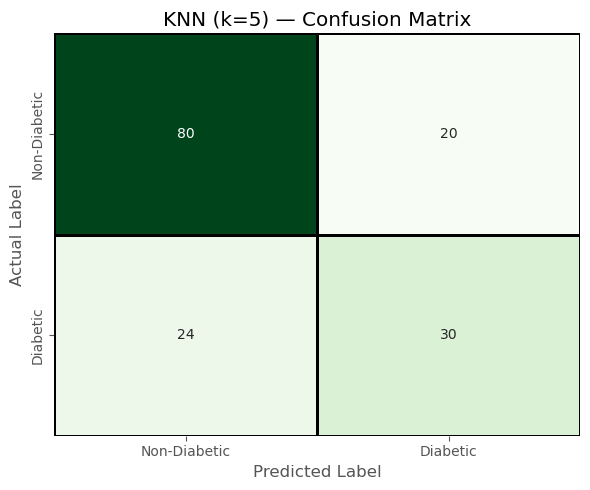

  FN (diabetic missed): 24  | TP (diabetic caught): 30


In [10]:
# Confusion matrix for KNN
fig, ax = plt.subplots(figsize=(6, 5))

cm_knn = confusion_matrix(y_test, knn_pred)

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'],
            ax=ax, linewidths=1, linecolor='black', cbar=False)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_title('KNN (k=5) — Confusion Matrix')
plt.tight_layout()
plt.show()

print(f"  FN (diabetic missed): {cm_knn[1][0]}  | TP (diabetic caught): {cm_knn[1][1]}")

In [11]:
# ─────────────────────────────────────────────────────
# COMPARISON TABLE
# Columns are ordered by our medical priority:
#   Recall > F1 > MCC > AUC > Accuracy
#
# The BEST value in each column is highlighted with ★
# ─────────────────────────────────────────────────────

results_df = pd.DataFrame(all_results)
results_df = results_df.set_index('Model')

# Reorder columns by priority
priority_order = ['Recall', 'F1-Score', 'MCC (Phi)', 'ROC-AUC', 'Precision', 'Accuracy']
results_df = results_df[priority_order]

# Round to 4 decimal places
print('=== BASELINE MODEL COMPARISON (sorted by priority) ===')
print(results_df.round(4).to_string())

print(f"\n📌 Best Recall:  {results_df['Recall'].idxmax()} ({results_df['Recall'].max():.4f})")
print(f"📌 Best F1:      {results_df['F1-Score'].idxmax()} ({results_df['F1-Score'].max():.4f})")
print(f"📌 Best MCC:     {results_df['MCC (Phi)'].idxmax()} ({results_df['MCC (Phi)'].max():.4f})")
print(f"📌 Best AUC:     {results_df['ROC-AUC'].idxmax()} ({results_df['ROC-AUC'].max():.4f})")

=== BASELINE MODEL COMPARISON (sorted by priority) ===
                     Recall  F1-Score  MCC (Phi)  ROC-AUC  Precision  Accuracy
Model                                                                         
Logistic Regression  0.5185    0.5600     0.3529   0.8085     0.6087    0.7143
Decision Tree        0.4630    0.5319     0.3406   0.7764     0.6250    0.7143
KNN (k=5)            0.5556    0.5769     0.3623   0.7756     0.6000    0.7143

📌 Best Recall:  KNN (k=5) (0.5556)
📌 Best F1:      KNN (k=5) (0.5769)
📌 Best MCC:     KNN (k=5) (0.3623)
📌 Best AUC:     Logistic Regression (0.8085)


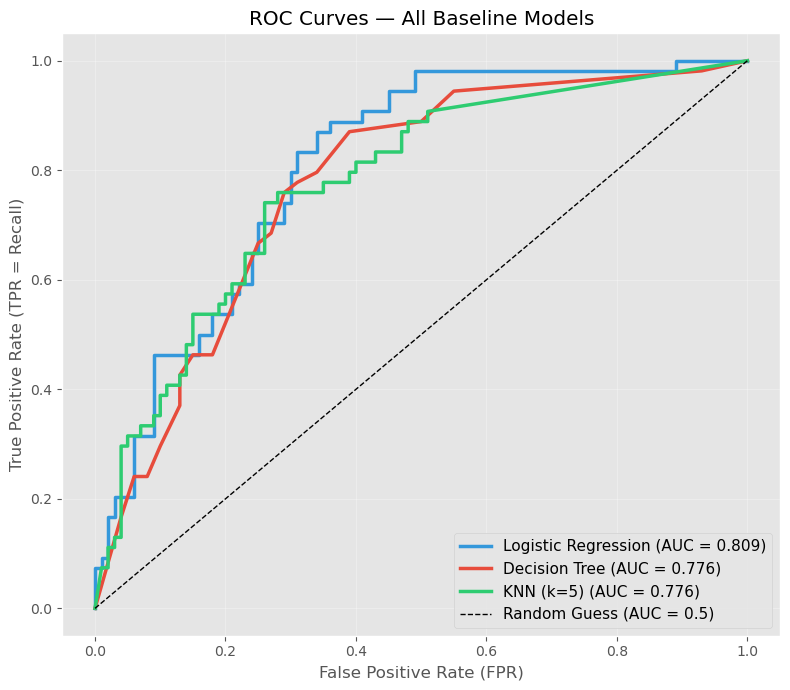

In [12]:
# ─────────────────────────────────────────────────────
# ROC CURVE — Receiver Operating Characteristic
#
# X-axis: False Positive Rate (FPR) = FP / (FP + TN)
# Y-axis: True Positive Rate (TPR) = TP / (TP + FN) = Recall
#
# The curve sweeps across ALL possible classification
# thresholds (not just 0.5). This shows how well the model
# can SEPARATE the two classes.
#
# AUC (Area Under Curve):
#   0.5 = random guessing (diagonal line)
#   1.0 = perfect separation
#   > 0.8 = good; > 0.9 = excellent
#
# Plotting all 3 models on the same axes lets us compare
# their discrimination ability directly.
# ─────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 7))

models_probs = {
    'Logistic Regression': lr_prob,
    'Decision Tree'      : dt_prob,
    'KNN (k=5)'          : knn_prob
}

colors = ['#3498db', '#e74c3c', '#2ecc71']

for (name, probs), color in zip(models_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name} (AUC = {auc:.3f})')

# Diagonal = random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess (AUC = 0.5)')

ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR = Recall)')
ax.set_title('ROC Curves — All Baseline Models')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# ─────────────────────────────────────────────────────
# WHAT NOTEBOOK 04 MUST BEAT:
# Record the best baseline score per metric here.
# Advanced models are only justified if they exceed ALL of these.
# ─────────────────────────────────────────────────────

print('╔══════════════════════════════════════════════════╗')
print('║       BASELINE TARGETS FOR NOTEBOOK 04           ║')
print('╠══════════════════════════════════════════════════╣')
for metric in priority_order:
    best_model = results_df[metric].idxmax()
    best_val   = results_df[metric].max()
    print(f'║  {metric:<12} > {best_val:.4f}  (set by {best_model:<25}) ║')
print('╠══════════════════════════════════════════════════╣')
print('║  📌 Any advanced model must beat EVERY line above ║')
print('║     to justify its complexity.                    ║')
print('╚══════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════╗
║       BASELINE TARGETS FOR NOTEBOOK 04           ║
╠══════════════════════════════════════════════════╣
║  Recall       > 0.5556  (set by KNN (k=5)                ) ║
║  F1-Score     > 0.5769  (set by KNN (k=5)                ) ║
║  MCC (Phi)    > 0.3623  (set by KNN (k=5)                ) ║
║  ROC-AUC      > 0.8085  (set by Logistic Regression      ) ║
║  Precision    > 0.6250  (set by Decision Tree            ) ║
║  Accuracy     > 0.7143  (set by Logistic Regression      ) ║
╠══════════════════════════════════════════════════╣
║  📌 Any advanced model must beat EVERY line above ║
║     to justify its complexity.                    ║
╚══════════════════════════════════════════════════╝
